In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
data = {
    'InvoiceNo': [f'5363{i}' for i in range(100)],
    'Quantity': np.random.randint(-10, 200, size=100),
    'UnitPrice': np.random.uniform(0.5, 50.0, size=100),
    'Country': np.random.choice(['United Kingdom', 'Germany', 'France', 'EIRE', 'Spain'], size=100)
}
d = pd.DataFrame(data)

In [24]:
sns.set_theme(style="whitegrid")
custom_palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
sns.set_palette(custom_palette)

In [25]:
print("=== DATASET PROFILE ===")
print(d.info())
print("\n=== MISSING VALUES ===")
print(d.isnull().sum())
print("\n=== DESCRIPTIVE STATISTICS ===")
print(d.describe())

=== DATASET PROFILE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   InvoiceNo  100 non-null    object 
 1   Quantity   100 non-null    int64  
 2   UnitPrice  100 non-null    float64
 3   Country    100 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 3.3+ KB
None

=== MISSING VALUES ===
InvoiceNo    0
Quantity     0
UnitPrice    0
Country      0
dtype: int64

=== DESCRIPTIVE STATISTICS ===
        Quantity   UnitPrice
count  100.00000  100.000000
mean    89.27000   23.582105
std     69.28172   14.889339
min    -10.00000    0.958258
25%     20.75000   10.756589
50%     86.50000   22.392991
75%    166.00000   37.197014
max    197.00000   49.566227


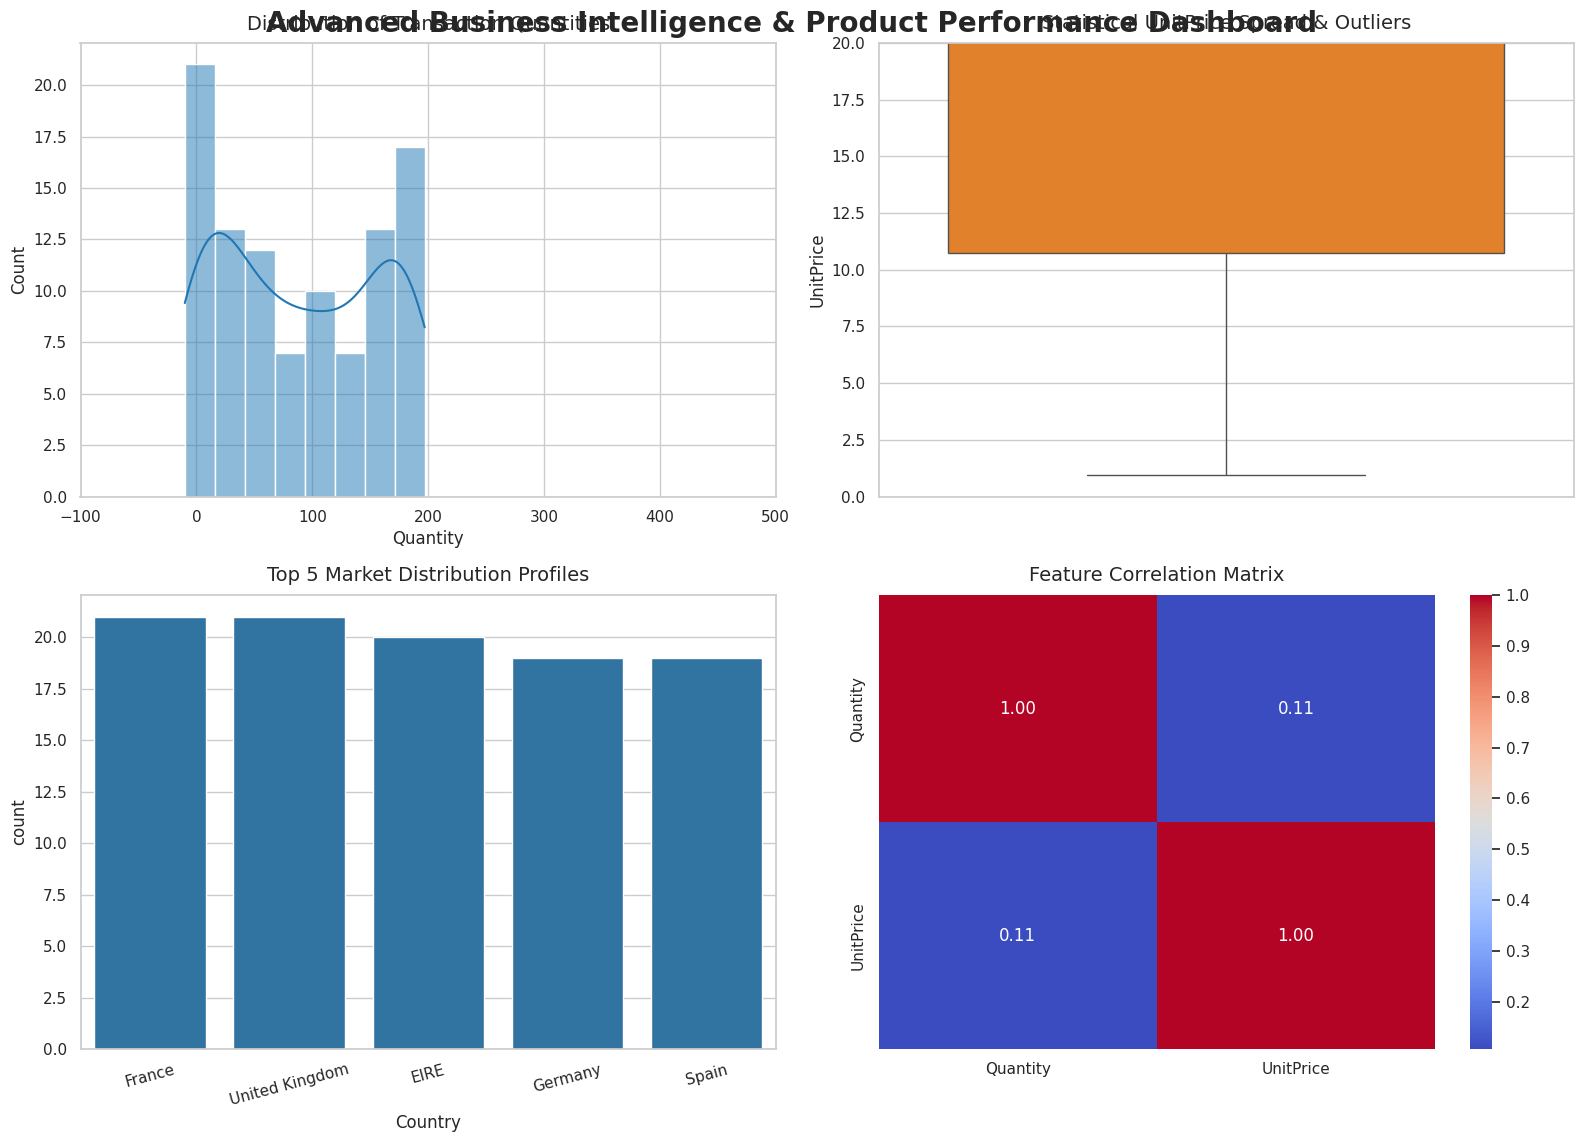

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Advanced Business Intelligence & Product Performance Dashboard', fontsize=20, fontweight='bold', y=0.95)

# --- Plot 1: Top-Left (Distribution of Quantity) ---
sns.histplot(data=d, x='Quantity', kde=True, ax=axes[0, 0], color='#1f77b4')
axes[0, 0].set_title('Distribution of Transaction Quantities', fontsize=14, pad=10)

# Optional: Limit x-axis if extreme wholesale quantities warp the look
axes[0, 0].set_xlim(-100, 500)

# Plot 2: Outlier & Quartile Identification
sns.boxplot(data=d, y='UnitPrice', ax=axes[0, 1], color='#ff7f0e')
axes[0, 1].set_title('Statistical UnitPrice Spread & Outliers', fontsize=14, pad=10)

# Limiting y-axis to focus on the main distribution body rather than massive extreme anomalies
axes[0, 1].set_ylim(0, 20)

# Plot 3: Top 5 Markets by Transaction Volumne
top_countries = d['Country'].value_counts().head(5).index
sns.countplot(data=d[d['Country'].isin(top_countries)], x='Country', ax=axes[1, 0], order=top_countries)
axes[1, 0].set_title('Top 5 Market Distribution Profiles', fontsize=14, pad=10)
axes[1, 0].tick_params(axis='x', rotation=15)

# Plot 4: Correlation Feature Mapping
numerical_d = d.select_dtypes(include=[np.number])
sns.heatmap(numerical_d.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('Feature Correlation Matrix', fontsize=14, pad=10)

# Final render command to clean up spacing across the grid
plt.tight_layout()
fig # Triggers the display of your final fully-populated canvas

plt.tight_layout()
plt.show()